# Paper 2 — Run the 16-Run Matrix (local · VS Code)

Runs all **16 experiments** (4 preprocessing versions × 4 models) on your RTX 4060
and collects the results. Everything else is already on disk (data, crop/align, the
de-duplicated split), so this just builds the fast **D1 resize-cache** and trains.

**How to run:** select the **`.venv` (Python 3.13)** kernel (top-right), then **Run All**.

**Timeline:** resize cache ~2 min · smoke ~30 s · **full matrix ~2–3 h (leave running).**

## 0. Setup & sanity checks

In [1]:
import os, sys
from pathlib import Path

REPO_DIR = Path(r"C:\dev\prethesis\paper2\training")   # <-- edit if your path differs
os.chdir(REPO_DIR)
print("cwd   :", os.getcwd())
print("python:", sys.executable)

import torch
print("torch :", torch.__version__, "| cuda:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

for sub in ["data/raw", "data/preprocessed/crop", "data/preprocessed/align", "splits/split.csv"]:
    print(("OK   " if (REPO_DIR / sub).exists() else "MISSING ") + sub)

cwd   : C:\dev\prethesis\paper2\training
python: c:\dev\prethesis\paper2\training\.venv\Scripts\python.exe
torch : 2.11.0+cu128 | cuda: True | NVIDIA GeForce RTX 4060
OK   data/raw
OK   data/preprocessed/crop
OK   data/preprocessed/align
OK   splits/split.csv


## 1. Build the D1 resize-cache (the speed fix)
Downscales raw images once to `data/preprocessed/resize/` so D1 stops re-decoding
full-size JPEGs every epoch. Idempotent — skips files that already exist.

In [2]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

CLASSES = ["heart", "oblong", "oval", "round", "square"]
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SRC, DST, SIZE = Path("data/raw"), Path("data/preprocessed/resize"), 256

made = skipped = 0
for c in CLASSES:
    (DST / c).mkdir(parents=True, exist_ok=True)
    for p in (SRC / c).rglob("*"):
        if p.suffix.lower() not in EXTS:
            continue
        out = DST / c / p.name
        if out.exists():
            skipped += 1; continue
        try:
            Image.open(p).convert("RGB").resize((SIZE, SIZE)).save(out, quality=90)
            made += 1
        except Exception as e:
            print("skip", p.name, e)
print(f"resize cache -> made {made}, existed {skipped}, total {sum(1 for c in CLASSES for _ in (DST/c).glob('*'))}")

resize cache -> made 5000, existed 0, total 5000


## 2. Verify the D1 fix is active

In [3]:
import importlib
from src import preprocessing
importlib.reload(preprocessing)
assert preprocessing.SOURCE_BY_VERSION["D1"] == "resize", "D1 fix NOT applied — check src/preprocessing.py"
for v in ["D1", "D2", "D3", "D4"]:
    print(v, "->", preprocessing.source_root_for(v, "data/raw", "data/preprocessed"))

D1 -> data\preprocessed\resize
D2 -> data\preprocessed\crop
D3 -> data\preprocessed\crop
D4 -> data\preprocessed\align


## 3. Fresh start (optional)
`True` clears previous run outputs for a clean matrix; set `False` to resume after an
interruption (run_matrix skips any cell that already has a `results.json`).

In [4]:
import shutil
FRESH_START = True
if FRESH_START and Path("runs").exists():
    shutil.rmtree("runs"); print("cleared runs/")
Path("runs").mkdir(exist_ok=True)

cleared runs/


## 4. Smoke test — confirm D1 now loads fast (~30 s)

In [5]:
!"{sys.executable}" -m src.train --model mobilenetv3small --preprocess D1 --epochs 1

[device] cuda
[mobilenetv3small_D1] e0 head val_acc=0.259 val_f1=0.258
[mobilenetv3small_D1] DONE test_acc=0.294 test_macro_f1=0.294


## 5. Run the full 16-run matrix  (~2–3 h — leave it running)
Streams progress per run. You can keep using your PC; it only uses the GPU. Resumable.

In [6]:
!"{sys.executable}" -m src.run_matrix --epochs 30 --extra --num-workers 6

[run] c:\dev\prethesis\paper2\training\.venv\Scripts\python.exe -m src.train --model resnet50 --preprocess D1 --batch-size 32 --epochs 30 --output-dir runs --num-workers 6
[device] cuda
[resnet50_D1] e0 head val_acc=0.387 val_f1=0.367
[resnet50_D1] e1 head val_acc=0.386 val_f1=0.368
[resnet50_D1] e2 head val_acc=0.401 val_f1=0.390
[resnet50_D1] e3 full val_acc=0.484 val_f1=0.478
[resnet50_D1] e4 full val_acc=0.540 val_f1=0.533
[resnet50_D1] e5 full val_acc=0.573 val_f1=0.568
[resnet50_D1] e6 full val_acc=0.610 val_f1=0.602
[resnet50_D1] e7 full val_acc=0.616 val_f1=0.613
[resnet50_D1] e8 full val_acc=0.647 val_f1=0.644
[resnet50_D1] e9 full val_acc=0.649 val_f1=0.646
[resnet50_D1] e10 full val_acc=0.661 val_f1=0.660
[resnet50_D1] e11 full val_acc=0.668 val_f1=0.667
[resnet50_D1] e12 full val_acc=0.675 val_f1=0.675
[resnet50_D1] e13 full val_acc=0.669 val_f1=0.668
[resnet50_D1] e14 full val_acc=0.675 val_f1=0.676
[resnet50_D1] e15 full val_acc=0.661 val_f1=0.655
[resnet50_D1] e16 full v

## 6. Results — run after the matrix finishes

In [9]:
import pandas as pd
df = pd.read_csv("runs/summary.csv")
acc = df.pivot(index="model", columns="preprocess", values="test_accuracy").round(4)
f1  = df.pivot(index="model", columns="preprocess", values="macro_f1").round(4)
print("Test accuracy (model x version)"); display(acc)
print("Macro-F1 (model x version)"); display(f1)
best = df.loc[df.test_accuracy.idxmax(), ["model", "preprocess", "test_accuracy"]]
print("Best overall:", dict(best))
print("Best version per model:", df.loc[df.groupby('model').test_accuracy.idxmax(),
      ['model','preprocess','test_accuracy']].to_dict('records'))

Test accuracy (model x version)


preprocess,D1,D2,D3,D4
model,,,,
efficientnetv2s,0.7787,0.8340,0.8826,0.8691
mobilenetv3small,0.6397,0.7436,0.8097,0.7908
resnet50,0.6802,0.7314,0.8313,0.8367
swint,0.7260,0.8043,0.8583,0.8866


Macro-F1 (model x version)


preprocess,D1,D2,D3,D4
model,,,,
efficientnetv2s,0.7803,0.8326,0.8817,0.8703
mobilenetv3small,0.6365,0.7431,0.8075,0.7875
resnet50,0.6796,0.7326,0.8304,0.8364
swint,0.7266,0.8069,0.8586,0.8878


Best overall: {'model': 'swint', 'preprocess': 'D4', 'test_accuracy': np.float64(0.8866396761133604)}
Best version per model: [{'model': 'efficientnetv2s', 'preprocess': 'D3', 'test_accuracy': 0.8825910931174089}, {'model': 'mobilenetv3small', 'preprocess': 'D3', 'test_accuracy': 0.8097165991902834}, {'model': 'resnet50', 'preprocess': 'D4', 'test_accuracy': 0.8367071524966262}, {'model': 'swint', 'preprocess': 'D4', 'test_accuracy': 0.8866396761133604}]


saved C:\dev\prethesis\paper2\paper_assets\fig_results_heatmap.png


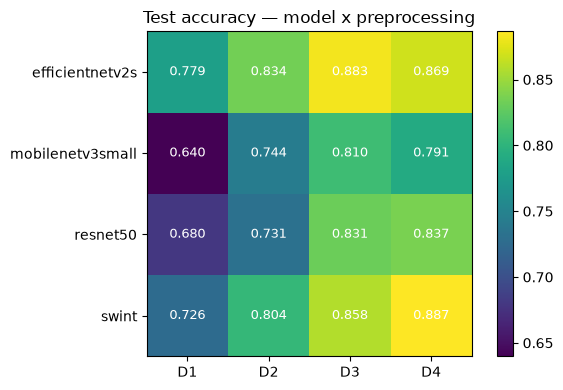

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(acc.values, cmap="viridis")
ax.set_xticks(range(len(acc.columns))); ax.set_xticklabels(acc.columns)
ax.set_yticks(range(len(acc.index)));   ax.set_yticklabels(acc.index)
for i in range(acc.shape[0]):
    for j in range(acc.shape[1]):
        ax.text(j, i, f"{acc.values[i, j]:.3f}", ha="center", va="center", color="w", fontsize=9)
ax.set_title("Test accuracy — model x preprocessing"); fig.colorbar(im); plt.tight_layout()
out = Path(r"C:\dev\prethesis\paper2\paper_assets\fig_results_heatmap.png")
fig.savefig(out, dpi=200, bbox_inches="tight"); fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
print("saved", out)

## Done
`runs/summary.csv` has the 16 rows; per-run confusion matrices are in
`runs/<model>_<version>/`. The results figure is saved to `paper_assets/`.
Tell me when it's finished and I'll help interpret it (esp. whether D4/align beat D3,
and how MobileNetV3 — your deployment target — did).